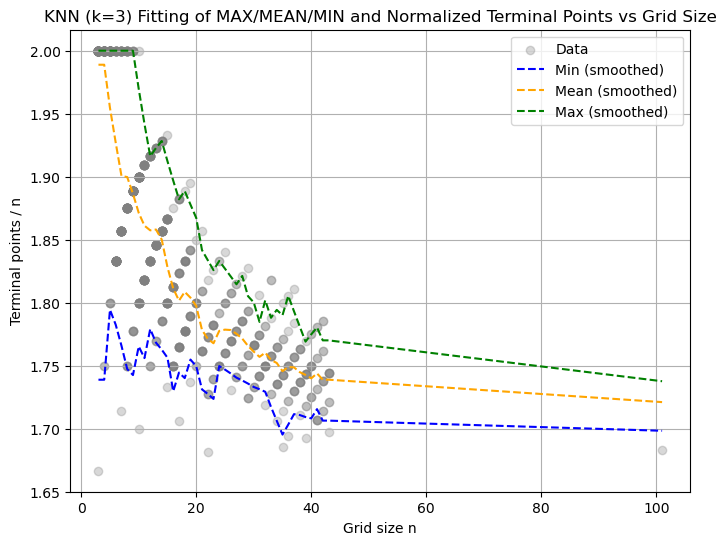

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Load experiment results
csv_path = 'experiment_results.csv'
df = pd.read_csv(csv_path)

# Compute normalized terminal points
df['terminal_num_points_over_n'] = df['terminal_num_points'] / df['n']

# Aggregate statistics by grid size
stats = df.groupby('n')['terminal_num_points_over_n'].agg(['min','mean','max']).reset_index()

# Prepare data for smoothing
X = stats['n'].values.reshape(-1, 1)
min_y, mean_y, max_y = stats['min'].values, stats['mean'].values, stats['max'].values

# Fit KNN (k=3) and predict smoothed values
knn = KNeighborsRegressor(n_neighbors=3)
min_smooth = knn.fit(X, min_y).predict(X)
mean_smooth = knn.fit(X, mean_y).predict(X)
max_smooth = knn.fit(X, max_y).predict(X)

# Plot raw data, original, and smoothed curves
plt.figure(figsize=(8, 6))
plt.scatter(df['n'], df['terminal_num_points_over_n'], color='gray', alpha=0.3, label='Data')
plt.plot(stats['n'], min_smooth, linestyle='--', color='blue', label='Min (smoothed)')
plt.plot(stats['n'], mean_smooth, linestyle='--', color='orange', label='Mean (smoothed)')
plt.plot(stats['n'], max_smooth, linestyle='--', color='green', label='Max (smoothed)')

plt.xlabel('Grid size n')
plt.ylabel('Terminal points / n')
plt.title('KNN (k=3) Fitting of MAX/MEAN/MIN and Normalized Terminal Points vs Grid Size')
plt.legend()
plt.grid(True)
plt.show()